# COCO starter set: EDA before cleaning → preprocessing → EDA after cleaning

**Data:** `data/coco/{train,val,test}/` built by `prepare_data.py`: Karpathy split, 30,496 / 4,998 / 5,000 images (`--train-size 30k`, the default; 10 photos that appeared in two splits were removed by `prepare_data.py`),
5+ human captions each, plus COCO object labels.

| Part | What it does |
|---|---|
| **0** | Setup and shared analysis functions (the *same* functions are used before and after cleaning) |
| **A** | **Raw EDA:** the data exactly as downloaded: integrity, full text statistics, image statistics, objects |
| **B** | **Preprocessing:** text cleaning and normalisation (step by step, with counts) and the image pipeline |
| **C** | **Clean EDA:** the same statistics re-computed on the cleaned data |
| **D** | **Before vs after comparison** |
| **E** | **Caption quality:** the mentor's question, "how do we tell a bad caption among the 5?" |

Outputs:
- figures go to `eda/figures/`
- numbers go to `eda/summary_raw.json`, `eda/summary_clean.json` and `eda/comparison.csv`
- cleaned data goes to `data/coco/` (see Part B)

The original `captions.json` files are **never modified**.

In [1]:
import json, os, re, random, sys, textwrap, unicodedata, warnings, math
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
sys.path.insert(0, str(ROOT / "eda"))
from eda_utils import (STOP, savefig, known_word, pct, norm_form, text_stats, char_stats, show_text_stats, plot_rare,
                       image_pass, find_duplicates, show_images as show_image_grid, CLIP_MEAN, CLIP_STD, IMAGENET_MEAN,
                       IMAGENET_STD, SIZE, resize_shorter, center_crop, eval_transform, random_resized_crop)

DATA = ROOT / "data"
COCO = DATA / "coco"
ANALYSIS = COCO / "analysis"
ANALYSIS.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
SEED = 42
rng = random.Random(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 90})
pd.set_option("display.max_colwidth", 160)

### Load the data (as downloaded)

In [2]:
records = {s: json.load(open(COCO / s / "captions.json", encoding="utf-8")) for s in SPLITS}
objects = {s: json.load(open(COCO / s / "objects.json", encoding="utf-8")) for s in SPLITS}

img_df = pd.DataFrame([{"split": s, "cocoid": r["cocoid"], "image": r["image"], "n_captions": len(r["captions"])}
                       for s in SPLITS for r in records[s]])
raw_df = pd.DataFrame([{"split": s, "cocoid": r["cocoid"], "raw_idx": i, "caption": c}
                       for s in SPLITS for r in records[s] for i, c in enumerate(r["captions"])])
lookup = {r["cocoid"]: {**r, "split": s} for s in SPLITS for r in records[s]}
split_of = dict(zip(img_df.cocoid, img_df.split))
print(f"{len(img_df):,} images, {len(raw_df):,} captions")

40,494 images, 202,604 captions


### Shared analysis functions

These functions live in [`eda_utils.py`](eda_utils.py), shared with the Conceptual Captions notebook.
`text_stats` computes **every text statistic** from a table of captions and their token lists. It is called once on the
raw tokens (Part A) and once on the cleaned tokens (Part C), so the before/after numbers are directly comparable.

| Group | Statistics |
|---|---|
| Size | captions, tokens, **types** (distinct words) |
| Lexical richness | **type–token ratio (TTR)**, **root TTR** (Guiraud: types/√tokens), **MTLD** (length-independent richness, threshold 0.72) |
| Rare words | **hapax legomena** (words seen once), **dis legomena** (seen twice), **frequency spectrum** (how many words occur exactly 1…10 times) |
| Laws | **Zipf's law** (rank–frequency slope), **Heaps' law** (vocabulary growth V = K·N^β) |
| Length | words and characters per caption, mean word length |
| Words | stopword share, top n-grams, **collocations** (bigrams ranked by PMI) |
| Grammar | **part-of-speech** mix, **lemmas** vs types (how many word forms are inflections of the same word) |
| Spelling | words that are not dictionary words *as written*; **likely typos** |
| Generalisation | vocabulary at min-frequency 5, coverage, **OOV** rate of val vs train, vocabulary overlap between splits (Jaccard) |

---
# Part A: Raw EDA (before any cleaning)

Raw tokens = the caption **split on whitespace, exactly as written**: case and punctuation stay attached.
So `"Man"`, `"man"` and `"man."` count as three different words. This is what a model would see without preprocessing.

## A1. Integrity and split check

In [3]:
overview = img_df.groupby("split").agg(images=("cocoid", "size"), captions=("n_captions", "sum")).loc[SPLITS]
overview["captions_per_image"] = (overview.captions / overview.images).round(3)
display(overview)
display(pd.crosstab(img_df.split, img_df.n_captions).loc[SPLITS])

ids = {s: set(img_df.loc[img_df.split == s, "cocoid"]) for s in SPLITS}
for a, b in combinations(SPLITS, 2):
    print(f"overlap {a}/{b}: {len(ids[a] & ids[b])}")
files_ok = all(sorted(p.name for p in (COCO / s / "images").iterdir()) == sorted(img_df.loc[img_df.split == s, "image"])
               for s in SPLITS)
print("image files match caption entries in every split:", files_ok)
print("empty captions:", int((raw_df.caption.str.strip() == "").sum()))

dup_exact_within = int(raw_df.duplicated(["cocoid", "caption"]).sum())
low = raw_df.caption.str.lower().str.replace(r"[^a-z0-9 ]", "", regex=True).str.split().str.join(" ")
dup_norm_within = int(pd.DataFrame({"cocoid": raw_df.cocoid, "n": low}).duplicated().sum())
across = low.value_counts()
print(f"duplicate captions within an image: exact {dup_exact_within}, ignoring case/punctuation {dup_norm_within}")
print(f"caption texts used for more than one image: {(across > 1).sum()}")
display(across.head(8).rename("images").to_frame())
INTEGRITY = {"images": len(img_df), "captions": len(raw_df), "overlap": 0, "files_ok": files_ok,
             "dup_within_exact": dup_exact_within, "dup_within_normalised": dup_norm_within,
             "texts_on_multiple_images": int((across > 1).sum())}

,images,captions,captions_per_image
split,,,
train,30496,152594,5.004
val,4998,25000,5.002
test,5000,25010,5.002


n_captions,5,6,7
split,,,
train,30385,108,3
val,4988,10,0
test,4990,10,0


overlap train/val: 0
overlap train/test: 0
overlap val/test: 0


image files match caption entries in every split: True
empty captions: 0


duplicate captions within an image: exact 56, ignoring case/punctuation 104
caption texts used for more than one image: 2548


,images
caption,
a man riding a wave on top of a surfboard,55
a man flying through the air while riding a skateboard,45
a man holding a tennis racquet on a tennis court,44
a large long train on a steel track,42
a public transit bus on a city street,42
a man riding skis down a snow covered slope,41
a man standing on a tennis court holding a racquet,38
a group of men on a field playing baseball,36


## A2. Raw text statistics

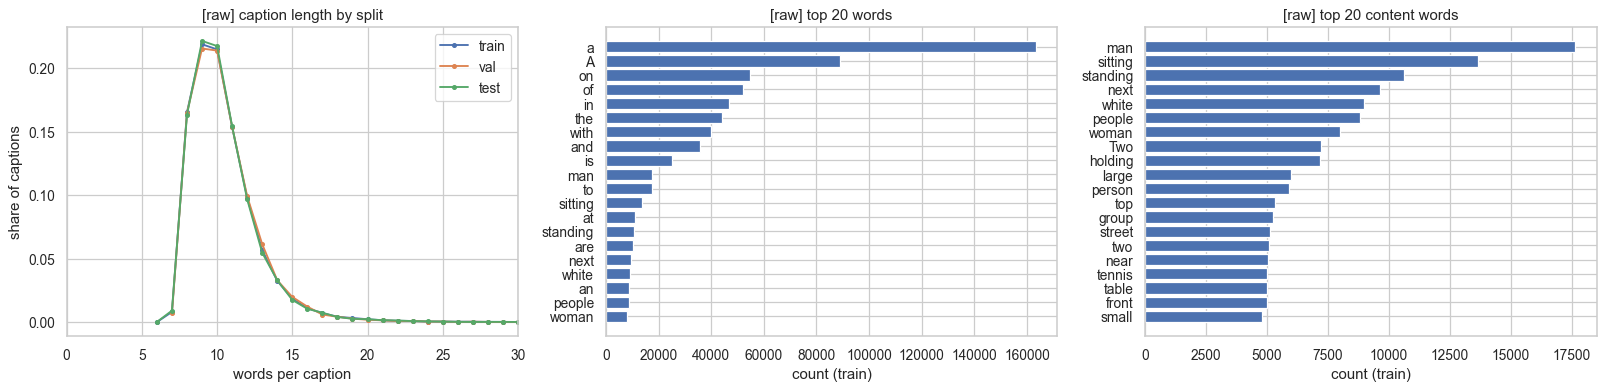

,raw
captions,2.026e+05
tokens,2.118e+06
types_all_splits,3.175e+04
train_tokens,1.595e+06
train_types,2.759e+04
ttr,0.01729
root_ttr,21.84
mtld,34.29
hapax,1.286e+04
hapax_pct_types,0.4662


,top bigrams,top trigrams,"collocations (PMI, freq ≥ 20)"
0,"on a (27,021)","next to a (5,862)",am unable (15.5)
1,"in a (17,097)","in front of (4,507)",polka dot (15.1)
2,"of a (17,059)","on top of (4,094)",stir fry (15.0)
3,"with a (15,490)","A group of (4,000)",peanut butter (14.4)
4,"in the (12,976)","sitting on a (3,792)",chain link (14.3)
5,"A man (11,730)","top of a (3,406)",newly married (14.3)
6,"on the (11,138)","front of a (3,111)",Big Ben (14.1)
7,"next to (9,556)","group of people (2,216)",I am (14.0)
8,"and a (7,905)","standing next to (1,642)",watering hole. (13.9)
9,"sitting on (6,977)","the side of (1,460)",blow drying (13.7)


,NOUN,VERB,ADJ
0,man (2310),is (3229),white (1231)
1,people (1144),sitting (1751),next (911)
2,woman (1076),are (1364),large (818)
3,person (774),standing (1203),small (647)
4,group (692),holding (947),black (621)
5,top (660),riding (605),red (578)
6,street (638),has (507),young (509)
7,train (638),playing (430),green (427)
8,tennis (629),walking (426),other (327)
9,front (603),parked (379),blue (318)


In [4]:
raw_df["text"] = raw_df.caption
raw_df["tokens"] = raw_df.caption.str.split()
S_raw, F_raw = text_stats(raw_df, "raw")
F_raw["split"] = raw_df.split
C_raw, P_raw = char_stats(raw_df.caption)
S_raw.update({f"chars_{k}": v for k, v in C_raw.items()})
show_text_stats(S_raw, F_raw, "raw")

### A2.1 Character level: how messy is the raw text?

In [5]:
display(pd.Series(C_raw).to_frame("raw captions").style.format(lambda v: pct(v) if isinstance(v, float) else v))
print("punctuation characters used:", dict(P_raw.most_common()))

,raw captions
has_uppercase,85.16%
starts_uppercase,85.02%
all_caps_word,1.23%
ends_with_period,75.09%
has_punctuation,76.28%
has_digit,0.35%
has_non_ascii,0.00%
has_double_space,1.15%
has_edge_whitespace,0.00%
distinct_characters,8900.00%


punctuation characters used: {'.': 152779, ',': 15102, "'": 2702, '-': 1874, '"': 1119, ':': 109, '/': 100, ';': 59, '?': 58, '!': 26, '&': 22, '(': 19, ')': 19, '#': 6, '$': 6, '+': 2, ']': 2, '>': 2, '`': 2, '=': 2, '[': 1, '%': 1, '_': 1, '@': 1, '*': 1}


### A2.2 Word-form variants

How many *different raw spellings* exist for the same word once case and punctuation are ignored?
Each variant is a separate vocabulary entry for a model, which wastes capacity and splits the training signal.

In [6]:
variants = defaultdict(Counter)
for w, c in F_raw["counts"].items():
    variants[norm_form(w)][w] += c
multi = {k: v for k, v in variants.items() if len(v) > 1 and k}
print(f"raw train types: {S_raw['train_types']:,} -> distinct words ignoring case/punctuation: {len(variants):,}")
print(f"words written in more than one way: {len(multi):,}")
ex = sorted(multi.items(), key=lambda kv: -sum(kv[1].values()))[:10]
display(pd.DataFrame([{"word": k, "raw variants (count)": ", ".join(f"'{w}' ({c})" for w, c in v.most_common(6))} for k, v in ex]))
S_raw["normalised_types"] = len(variants)
S_raw["words_with_variants"] = len(multi)

raw train types: 27,588 -> distinct words ignoring case/punctuation: 16,161
words written in more than one way: 5,891


,word,raw variants (count)
0,a,"'a' (163351), 'A' (88913), '""A' (2), ''A' (1), '""a"".' (1), 'A.' (1)"
1,on,"'on' (54925), 'on.' (417), 'ON' (397), 'On' (53), 'on,' (19), ',on' (1)"
2,of,"'of' (52069), 'OF' (340), 'of.' (7), 'Of' (1)"
3,the,"'the' (44208), 'The' (6716), 'THE' (516), '""The' (7), '""the' (1)"
4,in,"'in' (46807), 'IN' (323), 'In' (63), 'in.' (58), 'in.""' (1), 'in"".' (1)"
5,with,"'with' (40056), 'WITH' (254), 'with.' (3), 'With' (3), ',with' (1), 'with,' (1)"
6,and,"'and' (35789), 'AND' (206), 'And' (15), 'and,' (2), ',and' (1)"
7,is,"'is' (24932), 'IS' (509), 'is.' (15), 'Is' (10)"
8,man,"'man' (17646), 'Man' (779), 'man.' (147), 'MAN' (124), 'man,' (35), 'Man,' (5)"
9,to,"'to' (17524), 'TO' (45), 'To' (14), 'to.' (2)"


### A2.3 Rare words, Zipf and Heaps

* **Hapax legomena** are words seen exactly once. A model cannot learn a word from one example.
* **Zipf's law:** frequency ∝ rank^slope. A slope near −1 means a few words dominate and most are rare.
* **Heaps' law:** vocabulary V = K·N^β. β < 1 means new words keep appearing but more and more slowly. It tells us how
  much the vocabulary would grow with more data (e.g. moving from 30k to the full 113k training images).

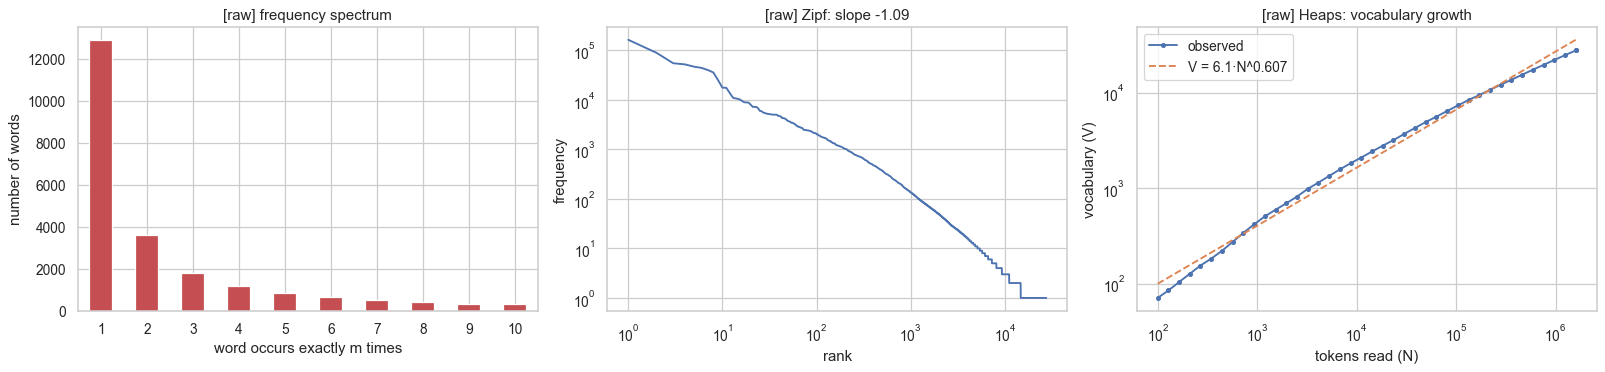

hapax: 12,862 words = 46.6% of the vocabulary, 0.81% of all tokens; dis legomena: 3,616 (13.1%)


In [7]:
plot_rare(F_raw, S_raw, "raw")

### A2.4 Spelling

In [8]:
print(f"raw types that are not dictionary words as written: {S_raw['types_not_dictionary_as_written']:,} "
      f"of {S_raw['train_types']:,} ({S_raw['types_not_dictionary_as_written'] / S_raw['train_types']:.1%})")
print("   (mostly capitalisation and attached punctuation, e.g. 'Man', 'table.')")
print(f"likely typos (rare non-dictionary words after ignoring case/punctuation): {S_raw['likely_typo_types']:,}")
print("examples:", ", ".join(rng.sample(F_raw["typos"], 30)))

raw types that are not dictionary words as written: 15,717 of 27,588 (57.0%)
   (mostly capitalisation and attached punctuation, e.g. 'Man', 'table.')
likely typos (rare non-dictionary words after ignoring case/punctuation): 2,593
examples: chocolatedipped, astro, ittybitty, helemt, glas, creepylooking, chandalier, terra, cafestyle, victorianera, pokka, backgroundis, bacardi, carboard, genetalia, grouop, spinx, wawtching, atvs, tootbrush, forhead, teo, playng, gifaffes, rinsk, veriety, jewelery, airporta, domo, polaroidlooking


### A2.5 Directional words (needed for the augmentation decision)

Flipping an image horizontally during training turns "left" into "right". If many captions use these words, flipping
would teach the model wrong captions unless we also swap the words.

In [9]:
lr = raw_df.caption.str.contains(r"\b(?:left|right)\b", case=False)
print(f"captions mentioning left/right: {lr.sum():,} ({lr.mean():.2%}); images with at least one: "
      f"{raw_df[lr].cocoid.nunique():,} ({raw_df[lr].cocoid.nunique() / len(img_df):.2%})")
display(raw_df[lr].sample(5, random_state=SEED)[["cocoid", "caption"]])
S_raw["left_right_captions"] = float(lr.mean())

captions mentioning left/right: 590 (0.29%); images with at least one: 560 (1.38%)


,cocoid,caption
181154,81897,An old bench is right on the oceans edge.
95764,364413,The cat is sleeping on the basket that was left on the desk.
179467,39589,A black cat guards what's left of a box of donuts.
111719,425644,A tall building with palm trees on the right side of it.
74060,282928,A man holding a piece of food in his left hand.


## A3. Raw image statistics

One pass over **all 40,494 images**:
- every image is fully decoded, to check for corruption
- size, mode and file size are recorded
- on a 256-px thumbnail we measure colour, brightness, contrast and sharpness (variance of the Laplacian: low = blurry)
- we compute a 64-bit perceptual difference hash (dHash) to find near-duplicate images

In [10]:
im_df, PIX_MEAN, PIX_STD = image_pass(
    (COCO / r.split / "images" / r.image, {"split": r.split, "cocoid": r.cocoid, "image": r.image}) for r in img_df.itertuples())
print("unreadable images:", int((~im_df.ok).sum()))
display(pd.crosstab(im_df.split, im_df["mode"]).loc[SPLITS])
display(im_df.groupby("split")[["width", "height", "aspect", "bytes", "brightness", "contrast", "sharpness"]].median().loc[SPLITS].round(3))

unreadable images: 0


mode,L,RGB
split,,
train,37,30459
val,11,4987
test,18,4982


,width,height,aspect,bytes,brightness,contrast,sharpness
split,,,,,,,
train,640.0,480.0,1.333,155819.0,0.447,0.224,0.014
val,640.0,480.0,1.333,153873.0,0.448,0.223,0.014
test,640.0,480.0,1.333,155944.5,0.444,0.225,0.014


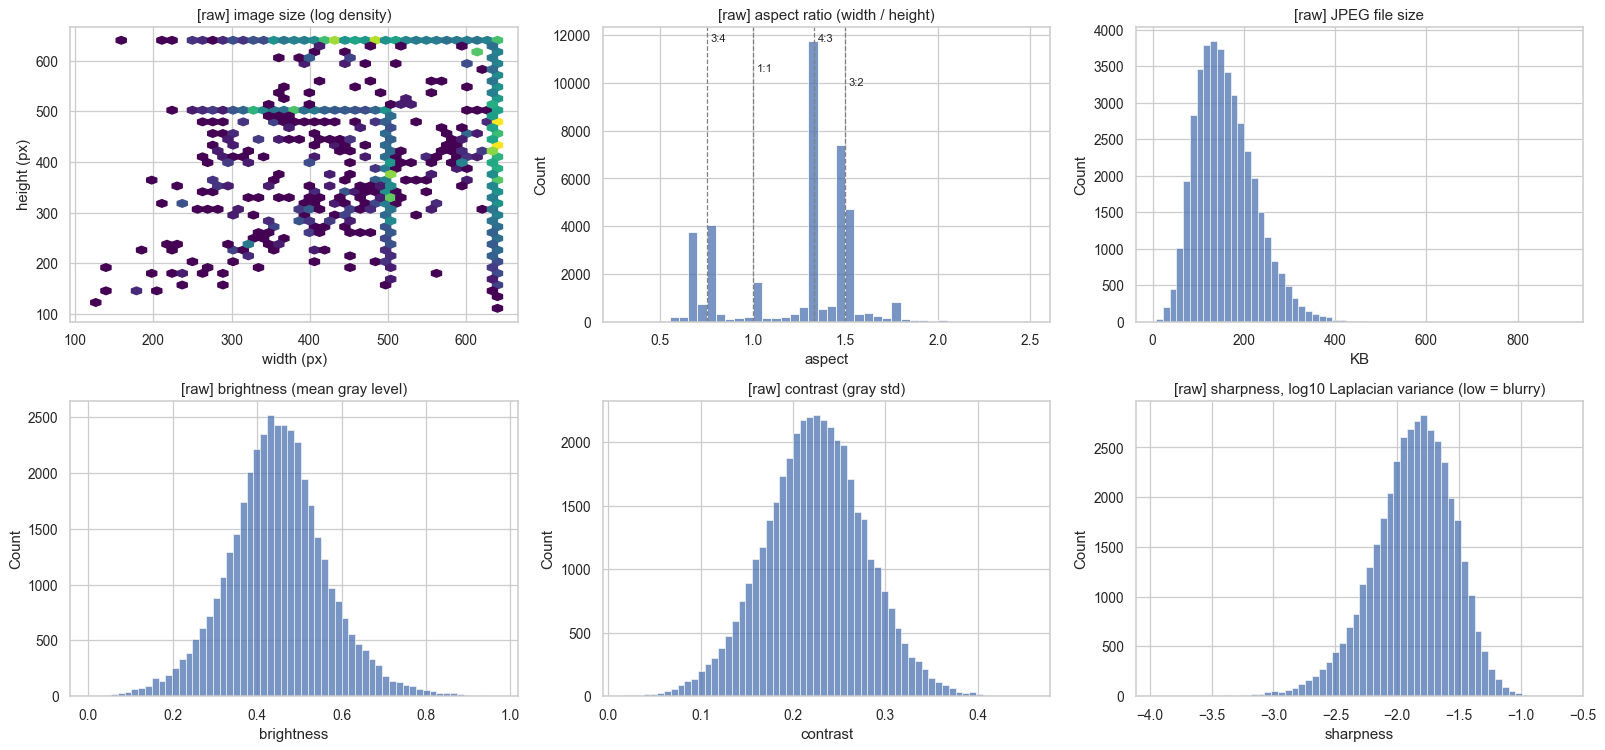

{
 "unreadable": 0,
 "grayscale": 66,
 "modes": {
  "RGB": 40428,
  "L": 66
 },
 "distinct_sizes": 1534,
 "max_side_640": 0.8315799871585914,
 "min_side_min": 111,
 "orientation": {
  "landscape": 0.717,
  "portrait": 0.237,
  "square-ish": 0.046
 },
 "top_sizes": {
  "640x480": 0.214,
  "640x427": 0.122,
  "480x640": 0.074,
  "500x375": 0.046
 },
 "pixel_mean": [
  0.4682,
  0.4451,
  0.4063
 ],
 "pixel_std": [
  0.2693,
  0.2645,
  0.2794
 ],
 "very_dark": 320,
 "very_bright": 75,
 "low_contrast": 226,
 "blurry_bottom1pct_threshold": 0.0016204718093749074
}


In [11]:
fig, ax = plt.subplots(2, 3, figsize=(18, 8.5))
ax[0, 0].hexbin(im_df.width, im_df.height, gridsize=40, bins="log", cmap="viridis")
ax[0, 0].set(xlabel="width (px)", ylabel="height (px)", title="[raw] image size (log density)")
sns.histplot(im_df.aspect.clip(0.3, 2.5), bins=np.arange(0.3, 2.55, 0.05), ax=ax[0, 1])
for v, lbl, y in [(3 / 4, "3:4", 0.95), (1, "1:1", 0.85), (4 / 3, "4:3", 0.95), (3 / 2, "3:2", 0.8)]:
    ax[0, 1].axvline(v, ls="--", c="gray", lw=1)
    ax[0, 1].text(v + 0.02, ax[0, 1].get_ylim()[1] * y, lbl, fontsize=9)
ax[0, 1].set(title="[raw] aspect ratio (width / height)")
sns.histplot(im_df.bytes / 1024, bins=60, ax=ax[0, 2]); ax[0, 2].set(title="[raw] JPEG file size", xlabel="KB")
sns.histplot(im_df.brightness, bins=60, ax=ax[1, 0]); ax[1, 0].set(title="[raw] brightness (mean gray level)")
sns.histplot(im_df.contrast, bins=60, ax=ax[1, 1]); ax[1, 1].set(title="[raw] contrast (gray std)")
sns.histplot(np.log10(im_df.sharpness), bins=60, ax=ax[1, 2]); ax[1, 2].set(title="[raw] sharpness, log10 Laplacian variance (low = blurry)")
plt.tight_layout(); savefig("raw_images"); plt.show()

q = im_df[["brightness", "contrast", "sharpness"]].quantile([.01, .99])
IMG_RAW = {
    "unreadable": int((~im_df.ok).sum()),
    "grayscale": int((im_df["mode"] == "L").sum()),
    "modes": im_df["mode"].value_counts().to_dict(),
    "distinct_sizes": int((im_df.width.astype(str) + "x" + im_df.height.astype(str)).nunique()),
    "max_side_640": float((im_df[["width", "height"]].max(axis=1) == 640).mean()),
    "min_side_min": int(im_df[["width", "height"]].min(axis=1).min()),
    "orientation": im_df.orientation.value_counts(normalize=True).round(3).to_dict(),
    "top_sizes": (im_df.width.astype(str) + "x" + im_df.height.astype(str)).value_counts(normalize=True).head(4).round(3).to_dict(),
    "pixel_mean": PIX_MEAN.round(4).tolist(), "pixel_std": PIX_STD.round(4).tolist(),
    "very_dark": int((im_df.brightness < 0.15).sum()), "very_bright": int((im_df.brightness > 0.85).sum()),
    "low_contrast": int((im_df.contrast < 0.08).sum()),
    "blurry_bottom1pct_threshold": float(q.loc[.01, "sharpness"]),
}
print(json.dumps(IMG_RAW, indent=1))

### A3.1 Extremes and near-duplicates

Images at the extremes (darkest, lowest contrast, blurriest, grayscale), plus duplicate images.

Duplicates are found in two stages:
1. **Candidates:** dHash differs in ≤ 3 of 64 bits.
2. **Confirmed:** same aspect ratio, and the 64×64 grayscale thumbnails correlate > 0.95. Correlation also catches
   copies with edited brightness or colour, while hashes alone are fooled by dark or vignetted images.

Duplicates **across splits** leak evaluation images into training (or val into test).

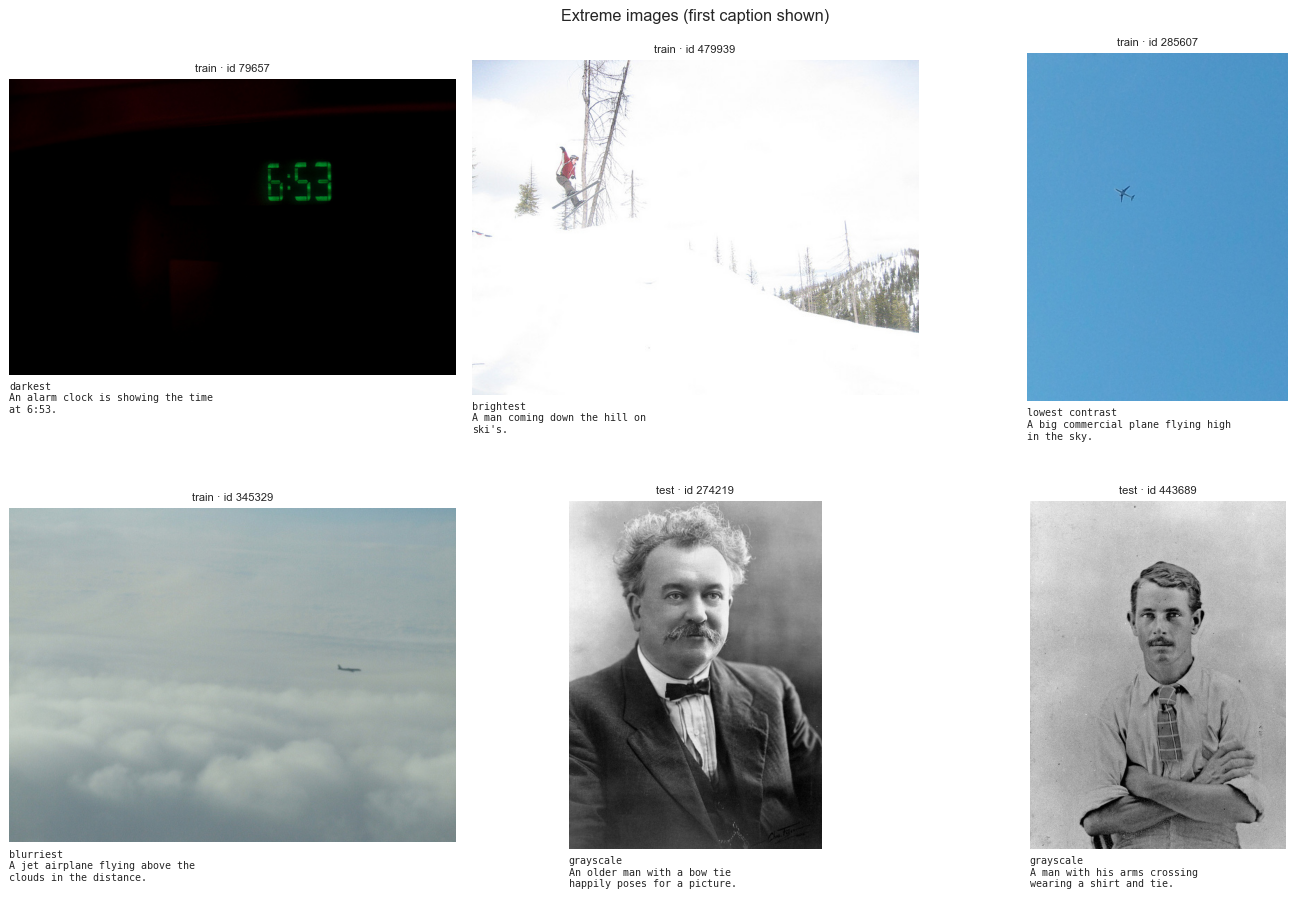

In [12]:
def show_images(items, *args, **kwargs):
    """items: list of (split, cocoid, text)."""
    show_image_grid([(COCO / s / "images" / lookup[cid]["image"], f"{s} · id {cid}", text) for s, cid, text in items],
                    *args, **kwargs)


ok = im_df[im_df.ok]
picks = [("darkest", ok.nsmallest(1, "brightness")), ("brightest", ok.nlargest(1, "brightness")),
         ("lowest contrast", ok.nsmallest(1, "contrast")), ("blurriest", ok.nsmallest(1, "sharpness")),
         ("grayscale", ok[ok["mode"] == "L"].sample(2, random_state=SEED))]
items = [(r.split, r.cocoid, f"{lbl}\n" + textwrap.fill(lookup[r.cocoid]["captions"][0], 34))
         for lbl, d in picks for r in d.itertuples()]
show_images(items, 3, "raw_image_extremes", "Extreme images (first caption shown)", text_lines=4)

hash candidates (≤3 of 64 bits differ): 370 -> confirmed on pixels: 4 (within a split: 4, across splits: 0)
rejected as false hash matches: 366


,a,b,split_a,split_b,hamming,aspect_diff,pixel_corr,confirmed,cross_split
322,15984,343629,train,train,1,0.0,0.999934,True,False
181,465129,535889,train,train,0,0.0,0.999624,True,False
358,247609,372203,train,train,2,0.0,0.996995,True,False
328,20333,62297,train,train,0,0.0,0.988646,True,False


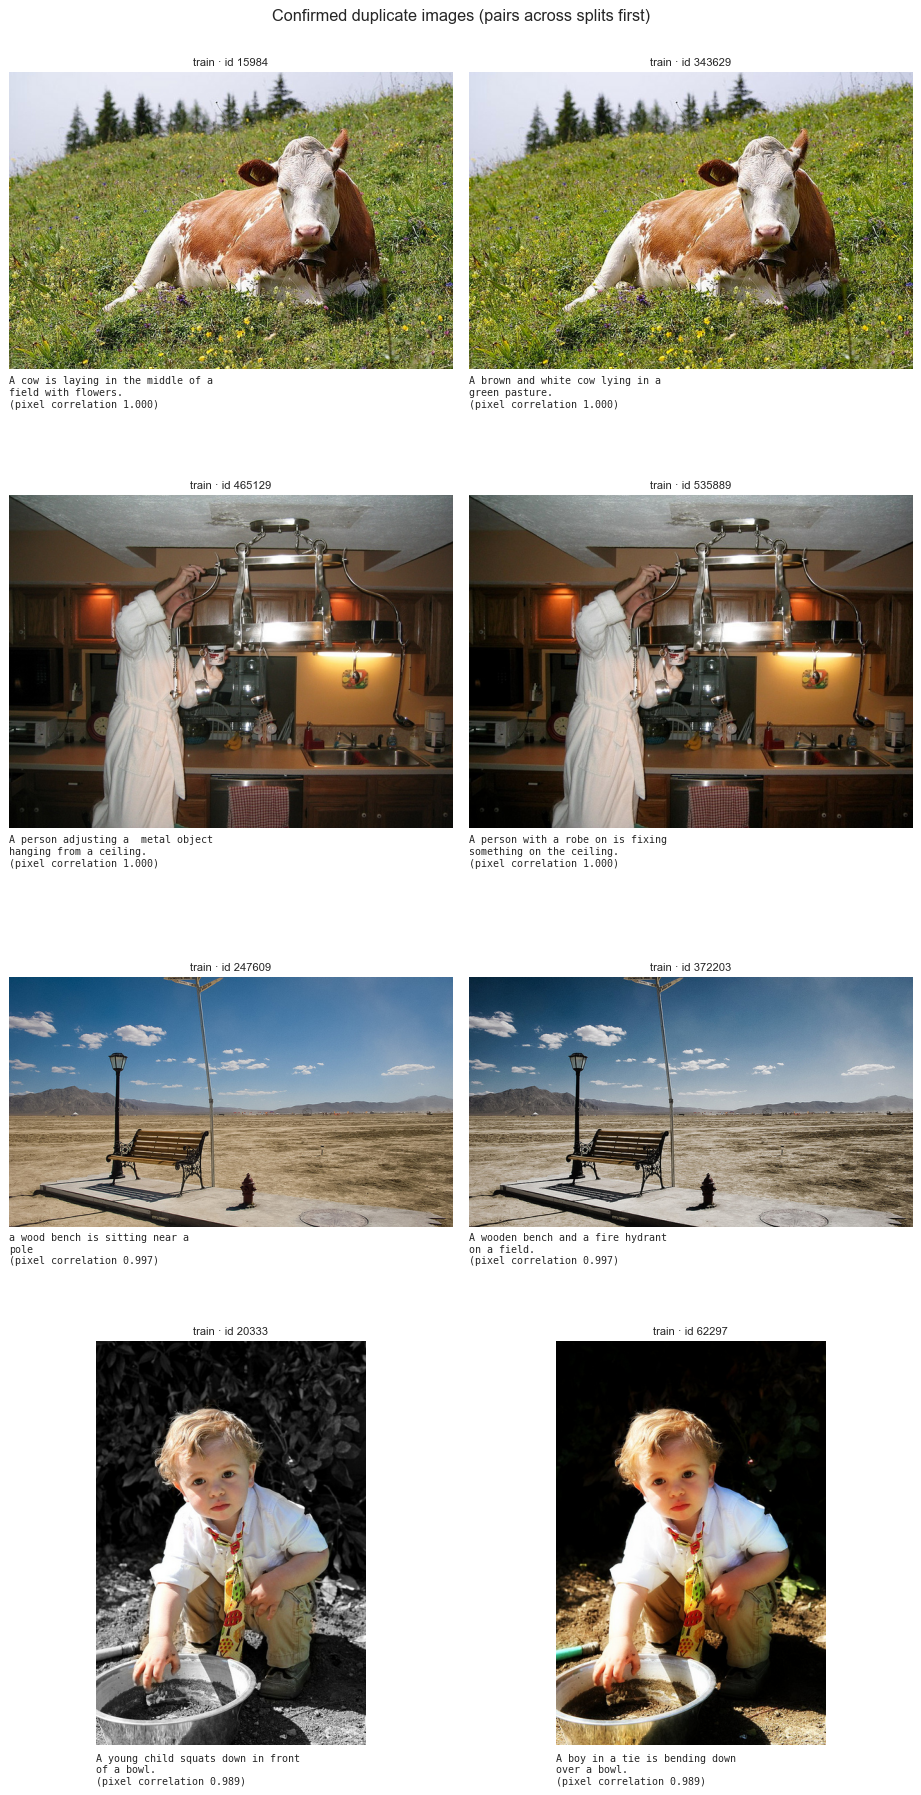

In [13]:
dup = find_duplicates(ok, "cocoid", "split", lambda cid: COCO / split_of[cid] / "images" / lookup[cid]["image"])
conf = dup[dup.confirmed] if len(dup) else dup
print(f"hash candidates (≤3 of 64 bits differ): {len(dup)} -> confirmed on pixels: {len(conf)} "
      f"(within a split: {int((~conf.cross_split).sum())}, across splits: {int(conf.cross_split.sum())})")
print(f"rejected as false hash matches: {len(dup) - len(conf)}")
display(conf.sort_values(["cross_split", "pixel_corr"], ascending=[False, False]).head(15))
show = conf.sort_values(["cross_split", "pixel_corr"], ascending=[False, False]).head(4)
items = []
for r in show.itertuples():
    for cid, s in [(r.a, r.split_a), (r.b, r.split_b)]:
        items.append((s, cid, textwrap.fill(lookup[cid]["captions"][0], 34) + f"\n(pixel correlation {r.pixel_corr:.3f})"))
if items:
    show_images(items, 2, "raw_near_duplicates", "Confirmed duplicate images (pairs across splits first)", text_lines=4)
conf[["a", "split_a", "b", "split_b", "hamming", "pixel_corr"]].to_csv(ANALYSIS / "duplicate_images.csv", index=False)
IMG_RAW["hash_candidates"] = int(len(dup))
IMG_RAW["duplicate_pairs"] = int(len(conf))
IMG_RAW["duplicate_pairs_cross_split"] = int(conf.cross_split.sum())
cross = conf[conf.cross_split]
IMG_RAW["duplicate_cross_split_detail"] = dict(Counter(f"{a}/{b}" for a, b in zip(cross.split_a, cross.split_b)))

## A4. Objects in images vs. objects in captions

From `objects.json` (official COCO labels, 80 categories). Text cleaning does not change these, so they are analysed once.

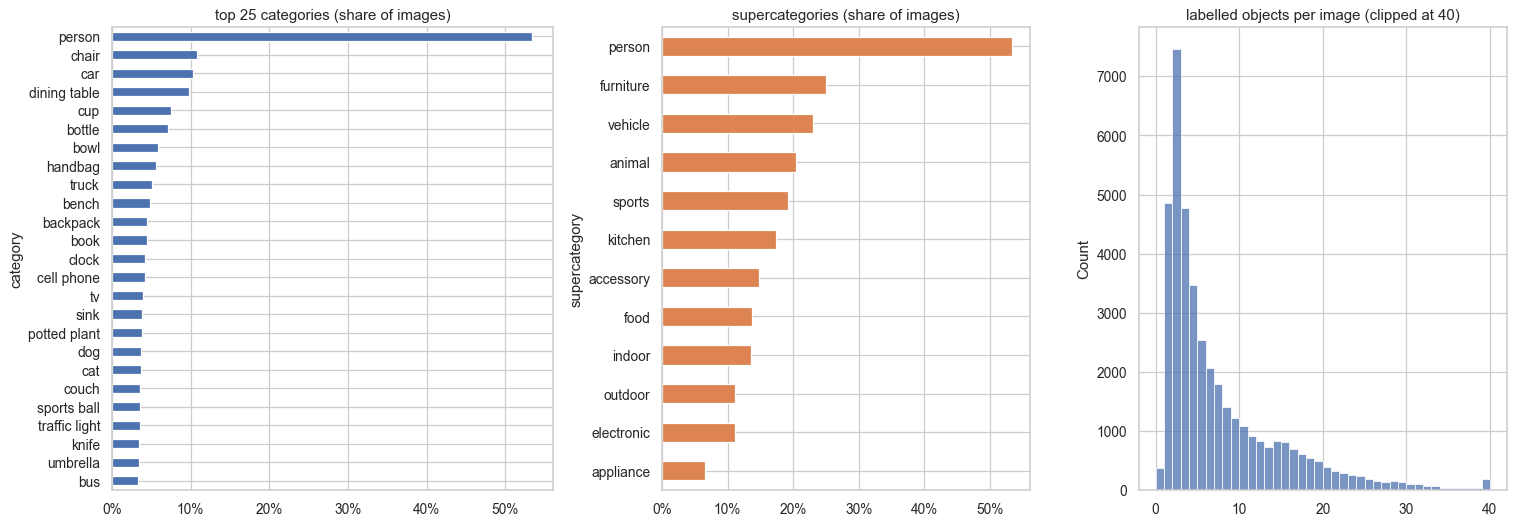

{
 "instances": 291829,
 "per_image_mean": 7.206721983503729,
 "per_image_median": 4.0,
 "images_without_objects": 367,
 "person_share": 0.5341285128661036,
 "size_share": {
  "small": 0.413,
  "medium": 0.342,
  "large": 0.244
 },
 "top_categories": {
  "person": 0.534,
  "chair": 0.109,
  "car": 0.103,
  "dining table": 0.098,
  "cup": 0.076,
  "bottle": 0.072,
  "bowl": 0.059,
  "handbag": 0.056
 },
 "rarest": {
  "scissors": 302,
  "parking meter": 261,
  "toaster": 74,
  "hair drier": 70
 },
 "split_category_spearman_min": 0.9606053687008601
}


In [14]:
ann = pd.DataFrame([{"cocoid": r["cocoid"], "split": s, "img_area": r["width"] * r["height"], **o}
                    for s in SPLITS for r in objects[s] for o in r["objects"]])
ann["rel_area"] = ann.area / ann.img_area
ann["size"] = pd.cut(ann.area, [-1, 32 ** 2, 96 ** 2, np.inf], labels=["small", "medium", "large"])
per_img = ann.groupby("cocoid").size().reindex(img_df.cocoid, fill_value=0)
img_cat = ann.drop_duplicates(["cocoid", "category"])
cat_freq = img_cat.category.value_counts() / len(img_df)
super_freq = ann.drop_duplicates(["cocoid", "supercategory"]).supercategory.value_counts() / len(img_df)

fig, ax = plt.subplots(1, 3, figsize=(17, 6), gridspec_kw={"width_ratios": [1.2, 1, 1]})
cat_freq.head(25)[::-1].plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set(title="top 25 categories (share of images)")
super_freq[::-1].plot.barh(ax=ax[1], color="#DD8452"); ax[1].set(title="supercategories (share of images)")
sns.histplot(per_img.clip(upper=40), bins=40, ax=ax[2]); ax[2].set(title="labelled objects per image (clipped at 40)")
for a in ax[:2]:
    a.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); savefig("objects"); plt.show()

split_cat = img_cat.groupby("split").category.value_counts().div(img_df.split.value_counts(), level="split").unstack(0).fillna(0)[SPLITS]
OBJ = {"instances": len(ann), "per_image_mean": float(per_img.mean()), "per_image_median": float(per_img.median()),
       "images_without_objects": int((per_img == 0).sum()), "person_share": float(cat_freq["person"]),
       "size_share": ann["size"].value_counts(normalize=True).round(3).to_dict(),
       "top_categories": cat_freq.head(8).round(3).to_dict(),
       "rarest": (cat_freq.tail(4) * len(img_df)).round().astype(int).to_dict(),
       "split_category_spearman_min": float(split_cat.corr("spearman").min().min())}
print(json.dumps(OBJ, indent=1))

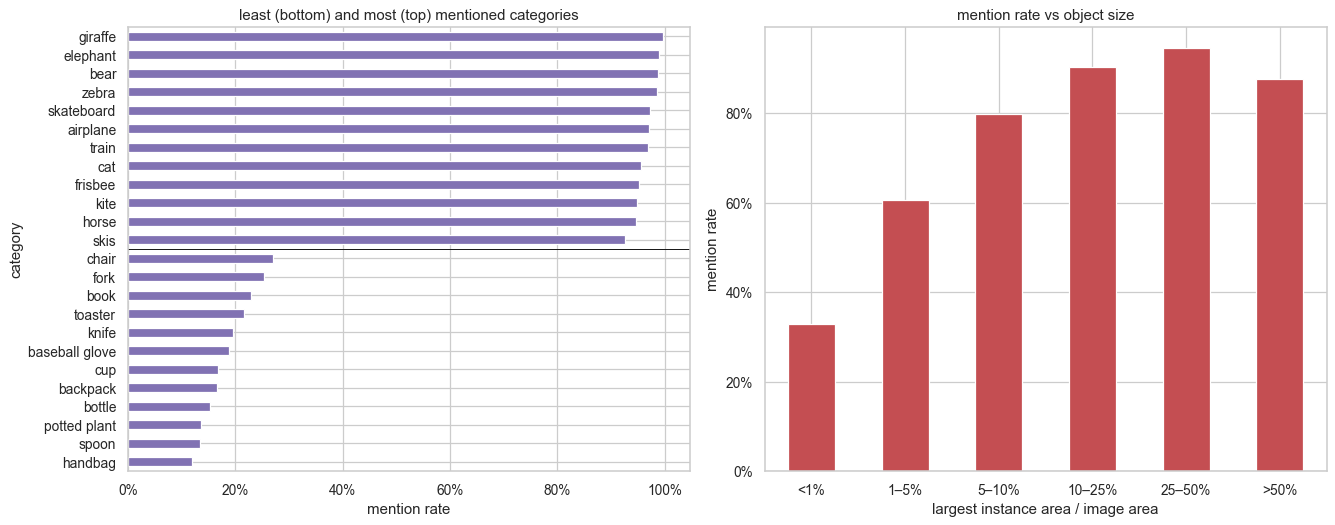

labelled categories mentioned in at least one caption: 61.7%


In [15]:
SYN = {  # comma-separated search terms; plural "s"/"es" is matched automatically
    "person": "person, people, man, men, woman, women, boy, girl, child, children, kid, guy, lady, ladies, player, "
              "skier, surfer, skateboarder, snowboarder, baby, babies, adult, crowd, rider, couple, family, teenager, "
              "someone, batter, catcher, pitcher, umpire, chef, worker, officer",
    "bicycle": "bicycle, bike", "motorcycle": "motorcycle, motorbike, bike, scooter",
    "airplane": "airplane, plane, jet, aircraft, airliner", "car": "car, vehicle, taxi", "sports ball": "ball",
    "dining table": "table", "couch": "couch, sofa", "potted plant": "plant", "tv": "tv, television",
    "cell phone": "phone, cellphone", "hot dog": "hot dog, hotdog", "donut": "donut, doughnut",
    "teddy bear": "teddy", "hair drier": "hair dryer, hair drier, dryer", "tennis racket": "racket, racquet",
    "baseball glove": "glove, mitt", "baseball bat": "bat", "skis": "ski", "wine glass": "glass",
    "remote": "remote, controller", "refrigerator": "refrigerator, fridge", "handbag": "handbag, purse, bag",
    "backpack": "backpack, bag", "traffic light": "traffic light, stoplight, stop light", "fire hydrant": "hydrant",
    "parking meter": "parking meter, meter", "laptop": "laptop, computer", "boat": "boat, ship", "cup": "cup, mug",
    "sandwich": "sandwich, burger", "cake": "cake, cupcake",
}


def pattern_for(name):
    terms = [t.strip() for t in SYN[name].split(",")] if name in SYN else [name, name.split()[-1]]
    alts = sorted({re.escape(t) for t in terms}, key=len, reverse=True)
    return re.compile(r"\b(?:" + "|".join(alts) + r")(?:s|es)?\b")


PATTERNS = {c: pattern_for(c) for c in ann.category.unique()}
caps_by_img = raw_df.groupby("cocoid").caption.apply(lambda x: " | ".join(x).lower())
pairs_m = ann.groupby(["cocoid", "category"]).rel_area.max().reset_index()
pairs_m["mentioned"] = [bool(PATTERNS[c].search(caps_by_img[i])) for i, c in zip(pairs_m.cocoid, pairs_m.category)]
mention = pairs_m.groupby("category").agg(images=("cocoid", "size"), rate=("mentioned", "mean"))
mention = mention[mention.images >= 50].sort_values("rate")
pairs_m["area_bin"] = pd.cut(pairs_m.rel_area, [0, .01, .05, .1, .25, .5, 1.0], labels=["<1%", "1–5%", "5–10%", "10–25%", "25–50%", ">50%"])
by_area = pairs_m.groupby("area_bin", observed=True).mentioned.mean()

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
pd.concat([mention.head(12), mention.tail(12)]).rate.plot.barh(ax=ax[0], color="#8172B3")
ax[0].axhline(11.5, c="k", lw=0.8)
ax[0].set(title="least (bottom) and most (top) mentioned categories", xlabel="mention rate")
by_area.plot.bar(ax=ax[1], color="#C44E52", rot=0)
ax[1].set(title="mention rate vs object size", xlabel="largest instance area / image area", ylabel="mention rate")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); savefig("object_mentions"); plt.show()
OBJ.update(mention_overall=float(pairs_m.mentioned.mean()), mention_by_area=by_area.round(3).to_dict(),
           least_mentioned=mention.head(5).rate.round(3).to_dict(), most_mentioned=mention.tail(5).rate.round(3).to_dict())
print(f"labelled categories mentioned in at least one caption: {pairs_m.mentioned.mean():.1%}")

---
# Part B: Preprocessing

## B1. Text pipeline

Based on the standard COCO captioning pipelines:
- the Karpathy split tokens (verified: *chef's → chefs*, *ice-cream → ice cream*)
- `prepro_labels.py` from ruotianluo/ImageCaptioning.pytorch
- the Show-Attend-Tell tutorial
- BLIP's `pre_caption`

| Step | What | Why |
|---|---|---|
| 1 | Unicode NFKC normalisation, trim, collapse whitespace | identical-looking characters become identical bytes |
| 2 | Lowercase | "Man" and "man" are the same word |
| 3 | Remove apostrophes (*chef's → chefs*) | Karpathy / COCO-community convention |
| 4 | Any other non-letter/digit character → space (hyphens, punctuation) | punctuation carries no content in captions |
| 5 | **Conservative spelling correction** (our addition, learned from train only, fully logged) | turns typos back into real words instead of `<unk>` |
| 6 | Drop exact duplicate captions of the same image | a duplicate adds no new information |
| 7 | Keep stopwords, keep all other captions (quality is only flagged, Part E) | a captioner must generate "a", "on", "of"; low consensus ≠ wrong |
| 8 | Vocabulary from **train only**, words with count ≥ 5, + `<pad> <start> <end> <unk>`; max length = 99th percentile | standard thresholds; val/test words must not leak into the vocabulary |

The original `captions.json` stays untouched: captioning metrics (`pycocoevalcap`) are computed against the **raw** references.

In [16]:
def step1(s): return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", s)).strip()
def step2(s): return s.lower()
def step3(s): return re.sub(r"['’`]", "", s)
def step4(s): return re.sub(r"[^a-z0-9]+", " ", s).strip()

steps = [("1 NFKC + whitespace", step1), ("2 lowercase", step2), ("3 remove apostrophes", step3), ("4 punctuation -> space", step4)]
cur = raw_df.caption.copy()
step_log = []
for name, fn in steps:
    new = cur.map(fn)
    step_log.append({"step": name, "captions changed": int((new != cur).sum()), "share": (new != cur).mean()})
    cur = new
raw_df["basic"] = cur
pd.DataFrame(step_log).style.format({"share": "{:.2%}"})

,step,captions changed,share
0,1 NFKC + whitespace,2333,1.15%
1,2 lowercase,172536,85.16%
2,3 remove apostrophes,2614,1.29%
3,4 punctuation -> space,154222,76.12%


### B1.1 Conservative spelling correction

A word is corrected only if **all** of these hold:
- it is not an English word (dictionary + WordNet)
- it appears at most twice in train
- it has at least 4 letters

It is replaced by the **most frequent train word one edit away** (one letter deleted, inserted, replaced, or two neighbours
swapped) that is itself an English word seen at least 10 times in train. Otherwise it is left alone.
The correction table is built from train counts only and applied to every split. All corrections are saved for review.

In [17]:
LETTERS = "abcdefghijklmnopqrstuvwxyz"

def edits1(w):
    splits = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    return set([a + b[1:] for a, b in splits if b] +
               [a + b[1] + b[0] + b[2:] for a, b in splits if len(b) > 1] +
               [a + c + b[1:] for a, b in splits if b for c in LETTERS] +
               [a + c + b for a, b in splits for c in LETTERS])

basic_tokens = raw_df.basic.str.split()
train_basic = Counter(t for ts in basic_tokens[raw_df.split == "train"] for t in ts)
all_basic = Counter(t for ts in basic_tokens for t in ts)

CORRECTIONS, unfixed = {}, []
for w in all_basic:
    if not w.isalpha() or len(w) < 4 or train_basic[w] > 2 or known_word(w):
        continue
    cands = [(train_basic[c], c) for c in edits1(w) if train_basic[c] >= 10 and known_word(c)]
    if cands:
        CORRECTIONS[w] = max(cands)[1]
    else:
        unfixed.append(w)

corr_df = pd.DataFrame([{"typo": w, "corrected": c, "typo_count_all_splits": all_basic[w], "corrected_train_count": train_basic[c]}
                        for w, c in sorted(CORRECTIONS.items())])
corr_df.to_csv(ANALYSIS / "spelling_corrections.csv", index=False)
raw_df["clean"] = basic_tokens.map(lambda ts: " ".join(CORRECTIONS.get(t, t) for t in ts))
n_tok_fixed = sum(all_basic[w] for w in CORRECTIONS)
print(f"words corrected: {len(CORRECTIONS):,} distinct ({n_tok_fixed:,} occurrences, "
      f"{(raw_df.clean != raw_df.basic).sum():,} captions changed)")
print(f"suspicious words left as they are (no safe correction): {len(unfixed):,}, e.g.", ", ".join(rng.sample(unfixed, 15)))
display(corr_df.sample(25, random_state=SEED).sort_values("typo"))
step_log.append({"step": "5 spelling correction", "captions changed": int((raw_df.clean != raw_df.basic).sum()),
                 "share": (raw_df.clean != raw_df.basic).mean()})

words corrected: 1,245 distinct (1,436 occurrences, 1,402 captions changed)
suspicious words left as they are (no safe correction): 1,179, e.g. oconnor, monacle, stethescope, seiko, onthe, elepwhnt, metroline, gueghard, parasurfing, nibiling, mercedez, freezby, intersecection, trainstop, pinup


,typo,corrected,typo_count_all_splits,corrected_train_count
43,antoher,another,1,1198
81,baaeball,baseball,1,3738
198,buildng,building,1,3529
210,cadles,candles,1,244
247,chikd,child,1,1419
297,convered,covered,1,1809
327,decroation,decoration,1,43
333,destk,desk,1,1932
442,foors,doors,1,212
462,funishings,furnishings,1,24


### B1.2 Duplicates, vocabulary and length

In [18]:
dup_mask = raw_df.duplicated(["cocoid", "clean"])
print(f"exact duplicate captions (after cleaning) removed: {int(dup_mask.sum())}")
clean_df = raw_df[~dup_mask].copy()
clean_df["text"] = clean_df.clean
clean_df["tokens"] = clean_df.clean.str.split()
caps_left = clean_df.groupby("cocoid").size()
before = img_df.set_index("cocoid").n_captions.reindex(caps_left.index)
print("images whose caption count changed:", int((caps_left != before).sum()),
      "| captions per image now:", caps_left.value_counts().sort_index().to_dict())
step_log.append({"step": "6 drop exact duplicates", "captions changed": int(dup_mask.sum()), "share": dup_mask.mean()})

train_counts_clean = Counter(t for ts in clean_df[clean_df.split == "train"].tokens for t in ts)
MIN_FREQ = 5
SPECIALS = ["<pad>", "<start>", "<end>", "<unk>"]
itos = SPECIALS + sorted(w for w, c in train_counts_clean.items() if c >= MIN_FREQ)
MAX_LEN = int(clean_df[clean_df.split == "train"].tokens.map(len).quantile(.99))
trunc = float((clean_df.tokens.map(len) > MAX_LEN).mean())
print(f"vocabulary: {len(itos):,} tokens (incl. {len(SPECIALS)} specials); max length {MAX_LEN} words, truncating {trunc:.2%} of captions")
STEP_LOG = pd.DataFrame(step_log)
STEP_LOG.style.format({"share": "{:.2%}"})

exact duplicate captions (after cleaning) removed: 105


images whose caption count changed:

 103 | captions per image now: {3: 2, 4: 92, 5: 40277, 6: 121, 7: 2}


vocabulary: 5,718 tokens (incl. 4 specials); max length 19 words, truncating 0.80% of captions


,step,captions changed,share
0,1 NFKC + whitespace,2333,1.15%
1,2 lowercase,172536,85.16%
2,3 remove apostrophes,2614,1.29%
3,4 punctuation -> space,154222,76.12%
4,5 spelling correction,1402,0.69%
5,6 drop exact duplicates,105,0.05%


## B2. Image pipeline

From CLIP's official `_transform` and BLIP's data transforms:

| Stage | Steps |
|---|---|
| Always | convert to **RGB** (fixes the grayscale images) |
| Evaluation / retrieval | resize shorter side to **224 (bicubic)** → **centre-crop 224×224** → scale to [0,1] → **normalise** with the encoder's mean/std (CLIP constants; ImageNet constants for a ResNet baseline) |
| Training (augmentation) | **random resized crop** (area 50–100 %, aspect 3/4–4/3) → 224×224; horizontal flip decided below |

The originals are **kept untouched**: different models need different input sizes (CLIP 224, BLIP 384), so resizing
happens when an image is loaded.

In [19]:
# "left"/"right" are rare and not always directional ("right next to", "in right colors"), so swapping the words
# would corrupt some captions. Rule: flip any image EXCEPT those with a caption mentioning left/right.
NO_FLIP = sorted(int(c) for c in raw_df[raw_df.caption.str.contains(r"\b(?:left|right)\b", case=False)].cocoid.unique())
FLIP_OK = True
print(f"captions mentioning left/right: {S_raw['left_right_captions']:.2%} -> horizontal flip allowed, "
      f"except for {len(NO_FLIP)} images ({len(NO_FLIP) / len(img_df):.2%}) whose captions mention left/right")
display(raw_df[raw_df.caption.str.contains(r"\bright next|\bright (?:colors|here|now)\b", case=False)].head(4)[["cocoid", "caption"]])

captions mentioning left/right: 0.29% -> horizontal flip allowed, except for 560 images (1.38%) whose captions mention left/right


,cocoid,caption
59,283,A glass of wine is shown wit a wine bottle right next to it on a table.
2038,7570,Nobody is working in the office right now.
10162,37958,A part of a peeled orange right next to the whole orange
11621,43535,a person standing right next to an elephant whiile giving them a kiss


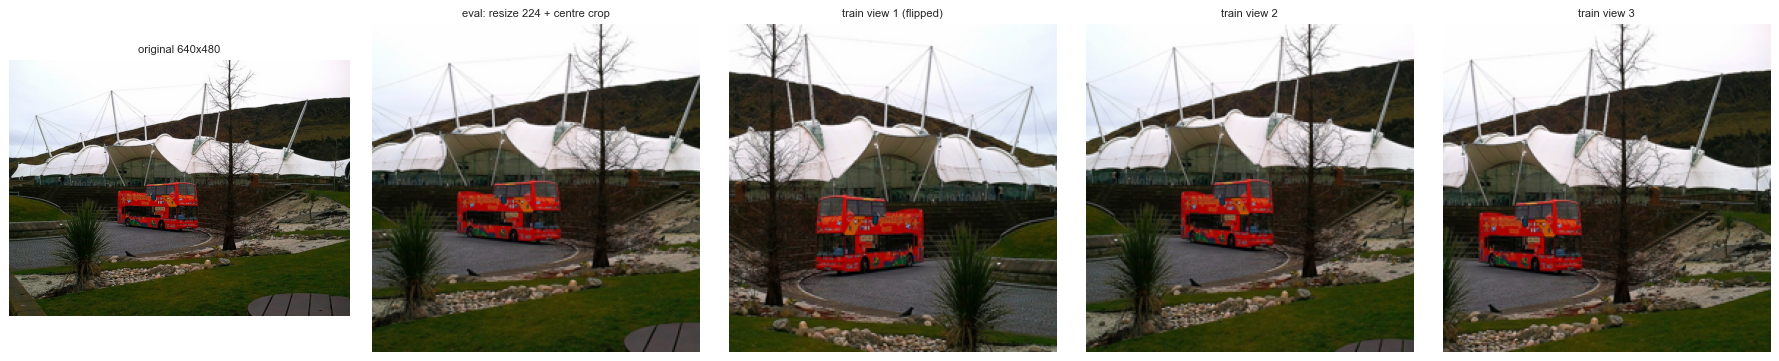

In [20]:
demo_id = img_df[img_df.split == "train"].sample(1, random_state=7).cocoid.iloc[0]
with Image.open(COCO / "train" / "images" / lookup[demo_id]["image"]) as im:
    orig = im.convert("RGB")
r_demo = random.Random(1)
views = [("original " + "x".join(map(str, orig.size)), orig),
         ("eval: resize 224 + centre crop", center_crop(resize_shorter(orig, SIZE), SIZE))]
for i in range(3):
    crop = random_resized_crop(orig, r_demo)
    flip = demo_id not in NO_FLIP and r_demo.random() < 0.5
    views.append((f"train view {i + 1}{' (flipped)' if flip else ''}", crop.transpose(Image.FLIP_LEFT_RIGHT) if flip else crop))
fig, ax = plt.subplots(1, len(views), figsize=(4 * len(views), 4))
for a, (t, v) in zip(ax, views):
    a.imshow(v); a.set_title(t, fontsize=9); a.axis("off")
plt.tight_layout(); savefig("image_pipeline", dpi=80); plt.show()

## B3. Save the processed data

| File | Contents |
|---|---|
| `data/coco/{split}/captions_clean.json` | per image: id, file, cleaned caption strings and their tokens |
| `data/coco/vocab.json` | vocabulary (index = id), min frequency, max length |
| `data/coco/preprocess_config.json` | every text and image setting and normalisation constant, so training code can reproduce the pipeline |
| `data/coco/analysis/` | spelling corrections, image statistics, caption quality flags (Part E) |

In [21]:
for s in SPLITS:
    g = clean_df[clean_df.split == s].sort_values(["cocoid", "raw_idx"]).groupby("cocoid")
    by_id = {cid: (list(d.clean), list(d.tokens)) for cid, d in g}
    out = [{"cocoid": r["cocoid"], "image": r["image"], "captions": by_id[r["cocoid"]][0], "tokens": by_id[r["cocoid"]][1]}
           for r in records[s]]
    json.dump(out, open(COCO / s / "captions_clean.json", "w", encoding="utf-8"))
json.dump({"itos": itos, "min_freq": MIN_FREQ, "max_len": MAX_LEN, "specials": SPECIALS}, open(COCO / "vocab.json", "w"), indent=1)
json.dump({
    "text": {"steps": [s for s, _ in steps] + ["5 spelling correction (analysis/spelling_corrections.csv)", "6 drop exact duplicates"],
             "keep_stopwords": True, "min_freq": MIN_FREQ, "max_len": MAX_LEN, "specials": SPECIALS,
             "evaluate_against": "raw captions.json"},
    "image": {"convert": "RGB", "size": SIZE, "eval": "resize shorter side (bicubic) + centre crop",
              "train": "random resized crop scale (0.5, 1.0) ratio (3/4, 4/3)",
              "horizontal_flip": "p=0.5, except images in no_flip_cocoids (a caption mentions left/right)",
              "no_flip_cocoids": NO_FLIP,
              "normalise": {"clip": {"mean": CLIP_MEAN.tolist(), "std": CLIP_STD.tolist()},
                            "imagenet": {"mean": IMAGENET_MEAN.tolist(), "std": IMAGENET_STD.tolist()},
                            "measured_on_this_data": {"mean": IMG_RAW["pixel_mean"], "std": IMG_RAW["pixel_std"]}}},
}, open(COCO / "preprocess_config.json", "w"), indent=1)
im_df.drop(columns=[c for c in ["error"] if c in im_df]).to_csv(ANALYSIS / "image_info.csv", index=False)
print("saved:", [f"{s}/captions_clean.json" for s in SPLITS], "vocab.json", "preprocess_config.json")

saved: ['train/captions_clean.json', 'val/captions_clean.json', 'test/captions_clean.json'] vocab.json preprocess_config.json


---
# Part C: Clean EDA (same statistics, after preprocessing)

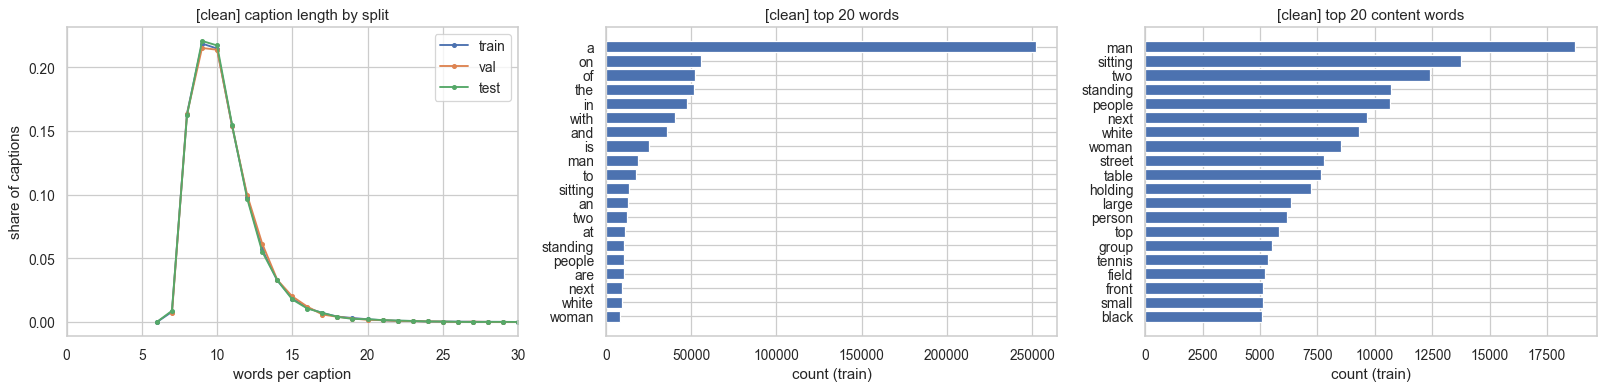

,clean
captions,2.025e+05
tokens,2.119e+06
types_all_splits,1.616e+04
train_tokens,1.596e+06
train_types,1.447e+04
ttr,0.009067
root_ttr,11.45
mtld,25.08
hapax,"5,117"
hapax_pct_types,0.3537


,top bigrams,top trigrams,"collocations (PMI, freq ≥ 20)"
0,"on a (27,131)","next to a (5,869)",am unable (15.3)
1,"in a (17,194)","a group of (4,773)",polka dot (15.1)
2,"of a (17,161)","in front of (4,537)",roman numerals (14.9)
3,"with a (15,575)","on top of (4,103)",stir fry (14.8)
4,"a man (14,999)","sitting on a (3,798)",baggage claim (14.7)
5,"in the (13,142)","top of a (3,413)",conveyor belt (14.6)
6,"on the (11,353)","front of a (3,125)",peanut butter (14.3)
7,"next to (9,568)","group of people (2,386)",onion rings (14.1)
8,"and a (7,951)","a couple of (2,276)",chain link (14.0)
9,"sitting on (7,008)","on a table (2,014)",newly married (14.0)


,NOUN,VERB,ADJ
0,man (2513),is (3327),white (1216)
1,people (1442),sitting (1661),next (885)
2,woman (1174),are (1410),large (819)
3,street (1044),standing (1268),small (744)
4,table (883),holding (962),black (659)
5,person (782),riding (606),young (572)
6,group (737),has (508),red (551)
7,tennis (731),playing (451),green (439)
8,top (727),walking (431),other (421)
9,field (691),looking (408),several (345)


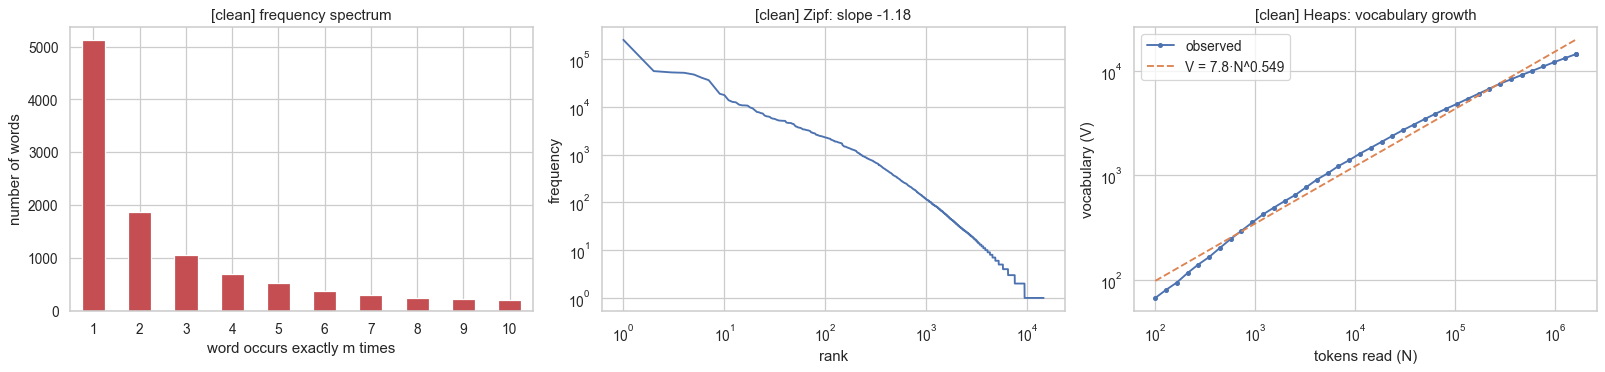

hapax: 5,117 words = 35.4% of the vocabulary, 0.32% of all tokens; dis legomena: 1,870 (12.9%)
punctuation characters left: {}


In [22]:
S_clean, F_clean = text_stats(clean_df, "clean")
F_clean["split"] = clean_df.split
C_clean, P_clean = char_stats(clean_df.clean)
S_clean.update({f"chars_{k}": v for k, v in C_clean.items()})
S_clean["normalised_types"] = len({norm_form(w) for w in F_clean["counts"]})
S_clean["words_with_variants"] = 0
S_clean["left_right_captions"] = float(clean_df.clean.str.contains(r"\b(?:left|right)\b").mean())
show_text_stats(S_clean, F_clean, "clean")
plot_rare(F_clean, S_clean, "clean")
print("punctuation characters left:", dict(P_clean))

### C1. Images after the pipeline

The evaluation transform is applied to 1,000 random train images. Expected result: every image is exactly 224×224×3,
and after CLIP normalisation each channel has mean ≈ 0 and std ≈ 1.

In [23]:
sample_ids = img_df[img_df.split == "train"].sample(1000, random_state=SEED)
shapes, t_sum, t_sq, t_n, raw_hist, new_hist = Counter(), np.zeros(3), np.zeros(3), 0, [], []
for r in sample_ids.itertuples():
    with Image.open(COCO / "train" / "images" / r.image) as im:
        raw_mode = im.mode
        x = eval_transform(im)
        if len(raw_hist) < 200:
            raw_hist.append(np.asarray(im.convert("RGB"), dtype=np.float32).reshape(-1, 3)[::50] / 255)
    shapes[(x.shape, raw_mode)] += 1
    px = x.reshape(-1, 3)
    t_sum += px.sum(0); t_sq += (px ** 2).sum(0); t_n += len(px)
    if len(new_hist) < 200:
        new_hist.append(px[::50])
T_MEAN = t_sum / t_n
T_STD = np.sqrt(t_sq / t_n - T_MEAN ** 2)
print("output shapes (shape, original mode) -> count:", dict(shapes))
IMG_CLEAN = {"output_shapes": {f"{k[0]} from mode {k[1]}": v for k, v in shapes.items()},
             "all_224x224x3": all(k[0] == (224, 224, 3) for k in shapes),
             "pixel_mean_after_norm": T_MEAN.round(4).tolist(), "pixel_std_after_norm": T_STD.round(4).tolist(),
             "distinct_sizes": 1}
print(json.dumps(IMG_CLEAN, indent=1))

output shapes (shape, original mode) -> count: {((224, 224, 3), 'RGB'): 999, ((224, 224, 3), 'L'): 1}
{
 "output_shapes": {
  "(224, 224, 3) from mode RGB": 999,
  "(224, 224, 3) from mode L": 1
 },
 "all_224x224x3": true,
 "pixel_mean_after_norm": [
  -0.0459,
  -0.0556,
  -0.0173
 ],
 "pixel_std_after_norm": [
  1.0142,
  1.0154,
  1.0171
 ],
 "distinct_sizes": 1
}


---
# Part D: Before vs after comparison

In [24]:
ROWS = [
    ("Captions", "captions"), ("Tokens (all splits)", "tokens"), ("Vocabulary: distinct words in train (types)", "train_types"),
    ("Distinct words ignoring case/punctuation", "normalised_types"), ("Words written in several ways", "words_with_variants"),
    ("Type–token ratio (train)", "ttr"), ("Root TTR (Guiraud)", "root_ttr"), ("MTLD", "mtld"),
    ("Hapax legomena (words seen once)", "hapax"), ("Hapax share of vocabulary", "hapax_pct_types"),
    ("Dis legomena (seen twice)", "dis_legomena"), ("Lemmas in train", "train_lemmas"), ("Types per lemma", "types_per_lemma"),
    ("Zipf slope", "zipf_slope"), ("Heaps β", "heaps_beta"), ("Heaps K", "heaps_K"),
    ("Mean caption length (words)", "len_mean"), ("99th percentile length", "len_p99"), ("Max length", "len_max"),
    ("Mean word length (chars)", "word_len_mean"), ("Stopword share", "stopword_share"),
    ("Types not dictionary words as written", "types_not_dictionary_as_written"), ("Likely typo words", "likely_typo_types"),
    ("Vocabulary at min-freq 5", "vocab_min5"), ("Train coverage at min-freq 5", "train_coverage_min5"),
    ("Val OOV tokens (min-freq 1)", "val_oov_tokens_min1"), ("Val OOV tokens (min-freq 5)", "val_oov_tokens_min5"),
    ("Val captions with ≥1 OOV (min-freq 5)", "val_oov_captions_min5"), ("Vocabulary overlap train/val (Jaccard)", "jaccard_train_val"),
    ("Captions with uppercase", "chars_has_uppercase"), ("Captions with punctuation", "chars_has_punctuation"),
    ("Captions with double spaces", "chars_has_double_space"), ("Distinct characters", "chars_distinct_characters"),
    ("POS: nouns", "pos_noun"), ("POS: verbs", "pos_verb"), ("POS: adjectives", "pos_adj"),
]
cmp = pd.DataFrame([{"metric": n, "raw": S_raw.get(k), "clean": S_clean.get(k)} for n, k in ROWS])
cmp["change"] = [(c - r) / r if isinstance(r, (int, float)) and r not in (0, None) else np.nan for r, c in zip(cmp.raw, cmp.clean)]
img_rows = pd.DataFrame([
    {"metric": "Image: distinct sizes", "raw": IMG_RAW["distinct_sizes"], "clean": IMG_CLEAN["distinct_sizes"]},
    {"metric": "Image: grayscale images", "raw": IMG_RAW["grayscale"], "clean": 0},
    *[{"metric": f"Image: channel {c} mean", "raw": IMG_RAW["pixel_mean"][i], "clean": IMG_CLEAN["pixel_mean_after_norm"][i]} for i, c in enumerate("RGB")],
    *[{"metric": f"Image: channel {c} std", "raw": IMG_RAW["pixel_std"][i], "clean": IMG_CLEAN["pixel_std_after_norm"][i]} for i, c in enumerate("RGB")],
])
COMPARISON = pd.concat([cmp, img_rows], ignore_index=True)
COMPARISON.to_csv(ROOT / "eda" / "comparison.csv", index=False)
COMPARISON.style.format({"raw": "{:,.4g}", "clean": "{:,.4g}", "change": "{:+.1%}"}, na_rep="")

,metric,raw,clean,change
0,Captions,2.026e+05,2.025e+05,-0.1%
1,Tokens (all splits),2.118e+06,2.119e+06,+0.0%
2,Vocabulary: distinct words in train (types),2.759e+04,1.447e+04,-47.6%
3,Distinct words ignoring case/punctuation,1.616e+04,1.447e+04,-10.5%
4,Words written in several ways,"5,891",0,-100.0%
5,Type–token ratio (train),0.01729,0.009067,-47.6%
6,Root TTR (Guiraud),21.84,11.45,-47.6%
7,MTLD,34.29,25.08,-26.9%
8,Hapax legomena (words seen once),1.286e+04,"5,117",-60.2%
9,Hapax share of vocabulary,0.4662,0.3537,-24.1%


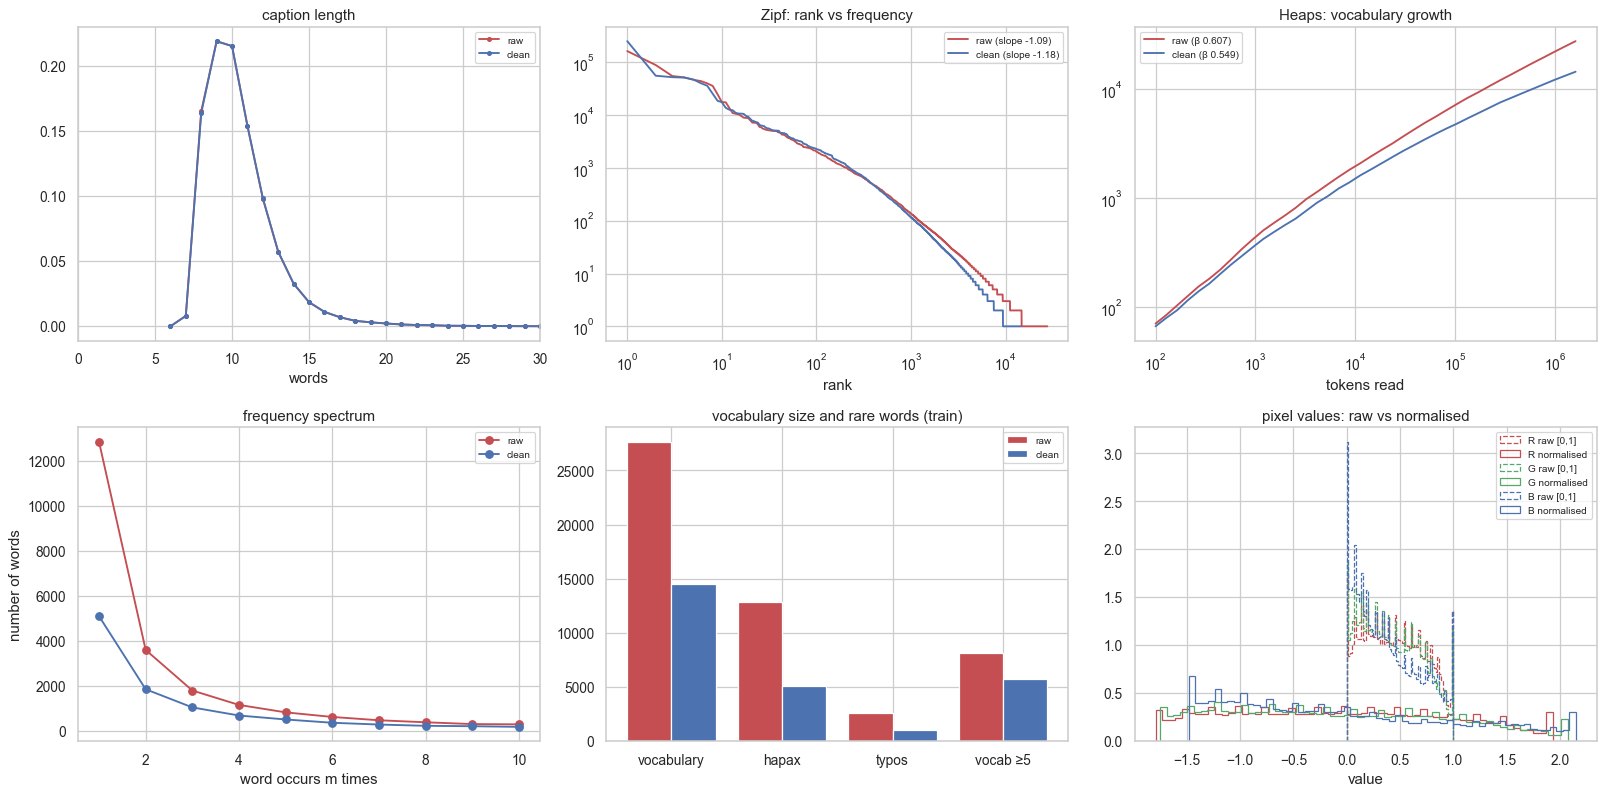

In [25]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
for F, S, lbl, c in [(F_raw, S_raw, "raw", "#C44E52"), (F_clean, S_clean, "clean", "#4C72B0")]:
    vals = F["n_words"].value_counts(normalize=True).sort_index()
    ax[0, 0].plot(vals.index, vals.values, "o-", ms=3, c=c, label=lbl)
    r, f = F["zipf"]; ax[0, 1].loglog(r, f, c=c, label=f"{lbl} (slope {S['zipf_slope']:.2f})")
    x, y = F["heaps"]; ax[0, 2].loglog(x, y, c=c, label=f"{lbl} (β {S['heaps_beta']:.3f})")
    ax[1, 0].plot(F["spectrum"].index, F["spectrum"].values, "o-", c=c, label=lbl)
ax[0, 0].set(title="caption length", xlabel="words", xlim=(0, 30))
ax[0, 1].set(title="Zipf: rank vs frequency", xlabel="rank")
ax[0, 2].set(title="Heaps: vocabulary growth", xlabel="tokens read")
ax[1, 0].set(title="frequency spectrum", xlabel="word occurs m times", ylabel="number of words")
keys = [("train_types", "vocabulary"), ("hapax", "hapax"), ("likely_typo_types", "typos"), ("vocab_min5", "vocab ≥5")]
xx = np.arange(len(keys))
ax[1, 1].bar(xx - 0.2, [S_raw[k] for k, _ in keys], 0.4, color="#C44E52", label="raw")
ax[1, 1].bar(xx + 0.2, [S_clean[k] for k, _ in keys], 0.4, color="#4C72B0", label="clean")
ax[1, 1].set_xticks(xx, [n for _, n in keys]); ax[1, 1].set(title="vocabulary size and rare words (train)")
raw_px, new_px = np.concatenate(raw_hist), np.concatenate(new_hist)
for i, c in enumerate(["#C44E52", "#55A868", "#4C72B0"]):
    ax[1, 2].hist(raw_px[:, i], bins=60, histtype="step", color=c, ls="--", density=True, label=f"{'RGB'[i]} raw [0,1]")
    ax[1, 2].hist(new_px[:, i], bins=60, histtype="step", color=c, density=True, label=f"{'RGB'[i]} normalised")
ax[1, 2].set(title="pixel values: raw vs normalised", xlabel="value")
for a in ax.ravel():
    a.legend(fontsize=8)
plt.tight_layout(); savefig("cmp_before_after"); plt.show()

---
# Part E: Caption quality (mentor's question)

*An image has 5 captions. If caption 4 is worse than caption 1, how do we tell?* This is computed on the **cleaned** captions.

1. **Consensus:** mean TF-IDF cosine similarity (stopwords removed) between a caption and the *other* captions of its image.
2. **Text flags:**
   - unusually short or long
   - contained a typo
   - filler opening ("a picture of …")
   - bottom 5 % consensus

Caveat: low consensus does not prove a caption is wrong. It may be a paraphrase or describe another valid part of the scene.

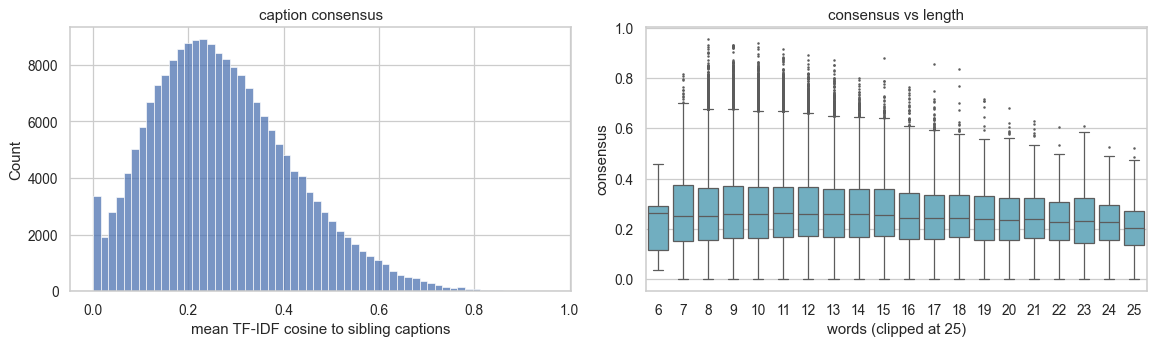

{
 "consensus_mean": 0.27312220045881336,
 "consensus_zero": 0.015061802774334688,
 "rho_len_consensus": 0.0066283324714537985,
 "flags": {
  "flag_short": 0.008,
  "flag_long": 0.008,
  "flag_had_typo": 0.0069,
  "flag_generic_start": 0.0235,
  "flag_low_consensus": 0.05
 },
 "flag_any": 0.09235601163462535,
 "flag_2plus": 0.004044464417108233,
 "short_threshold": 8.0,
 "long_threshold": 19.0
}


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

clean_df = clean_df.reset_index(drop=True)
vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, stop_words=sorted(STOP), min_df=2)
vec.fit(clean_df.loc[clean_df.split == "train", "clean"])
X = vec.transform(clean_df.clean)
consensus, img_agree = np.zeros(len(clean_df)), {}
for cid, idx in clean_df.groupby("cocoid").indices.items():
    S_ = (X[idx] @ X[idx].T).toarray()
    k = len(idx)
    consensus[idx] = (S_.sum(1) - S_.diagonal()) / (k - 1)
    img_agree[cid] = S_[np.triu_indices(k, 1)].mean()
clean_df["consensus"] = consensus

n = clean_df.tokens.map(len)
p01, p99 = n.quantile([.01, .99])
GENERIC = re.compile(r"^(?:there is |this is |here is )?(?:a |an )?(?:picture|photo|photograph|image|close up|closeup|view|shot)s? (?:of|showing)\b")
clean_df["flag_short"] = n < p01
clean_df["flag_long"] = n > p99
clean_df["flag_had_typo"] = clean_df.clean != clean_df.basic
clean_df["flag_generic_start"] = clean_df.clean.str.match(GENERIC)
clean_df["flag_low_consensus"] = clean_df.consensus < clean_df.consensus.quantile(.05)
flag_cols = [c for c in clean_df.columns if c.startswith("flag_")]
clean_df["n_flags"] = clean_df[flag_cols].sum(axis=1)
clean_df[["split", "cocoid", "raw_idx", "caption", "clean", "consensus"] + flag_cols].to_csv(ANALYSIS / "caption_flags.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(clean_df.consensus, bins=60, ax=ax[0]); ax[0].set(title="caption consensus", xlabel="mean TF-IDF cosine to sibling captions")
sns.boxplot(x=n.clip(upper=25), y=clean_df.consensus, ax=ax[1], fliersize=1, color="#64B5CD"); ax[1].set(title="consensus vs length", xlabel="words (clipped at 25)")
plt.tight_layout(); savefig("consensus"); plt.show()

QUALITY = {"consensus_mean": float(clean_df.consensus.mean()), "consensus_zero": float((clean_df.consensus == 0).mean()),
           "rho_len_consensus": float(stats.spearmanr(n, clean_df.consensus).statistic),
           "flags": clean_df[flag_cols].mean().round(4).to_dict(), "flag_any": float((clean_df.n_flags > 0).mean()),
           "flag_2plus": float((clean_df.n_flags >= 2).mean()), "short_threshold": float(p01), "long_threshold": float(p99)}
print(json.dumps(QUALITY, indent=1))

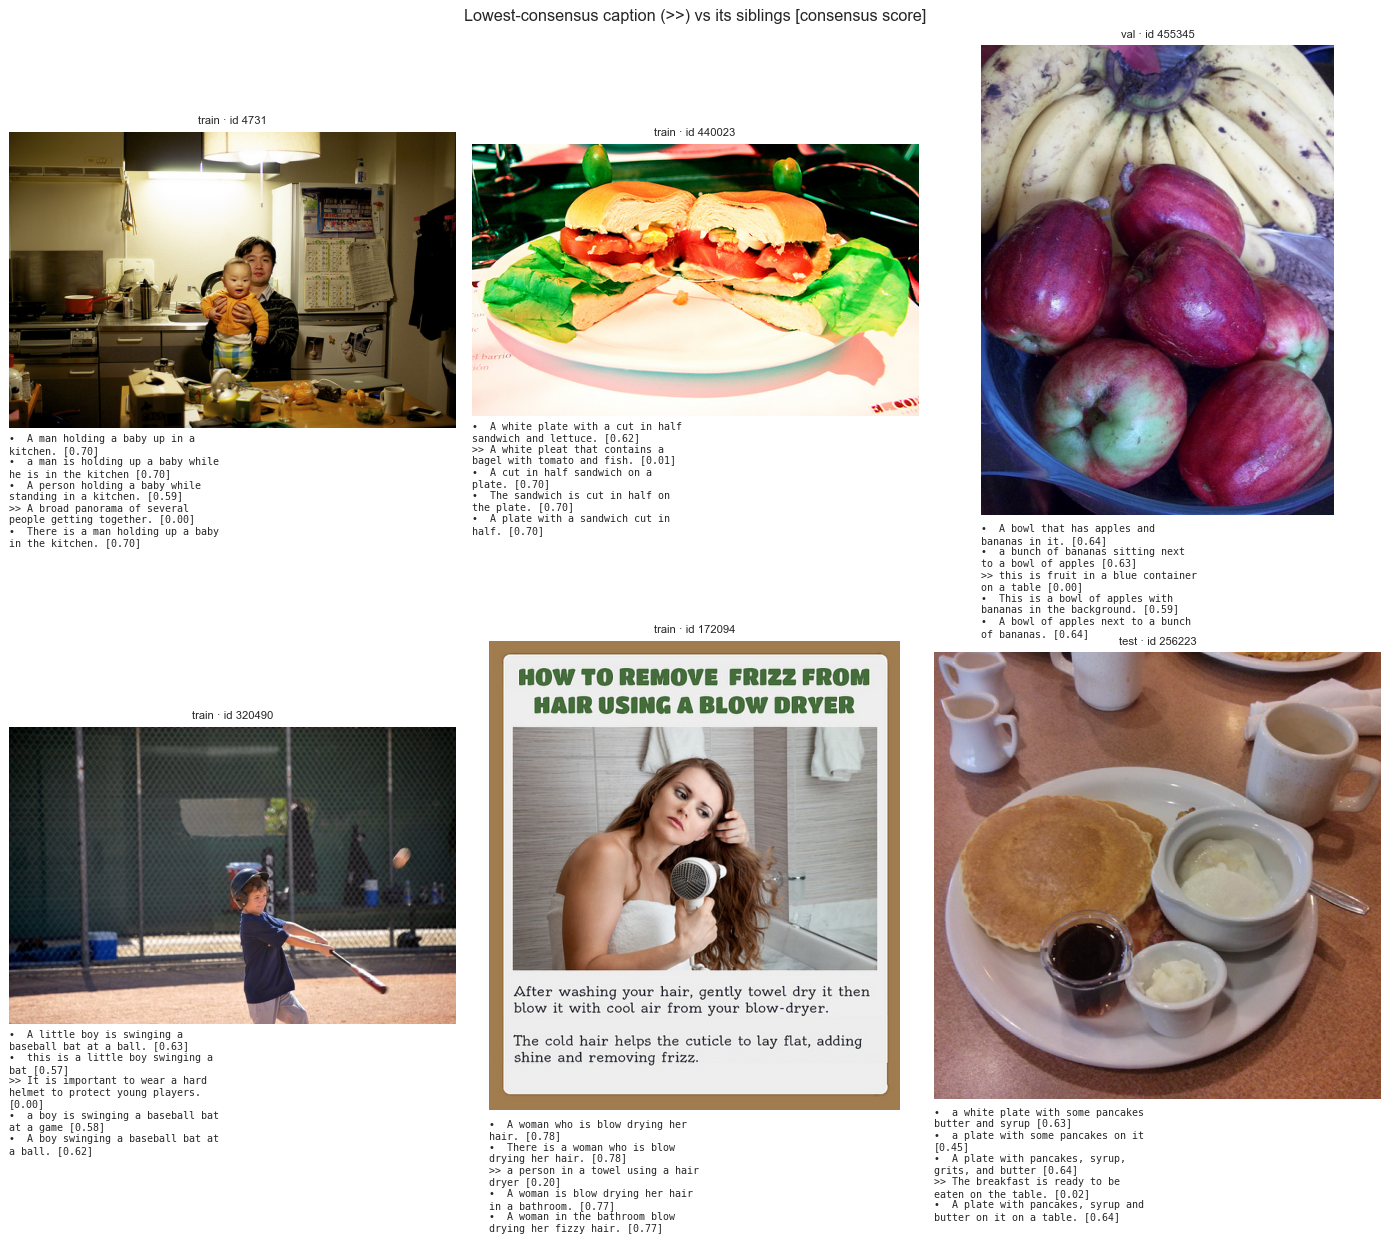

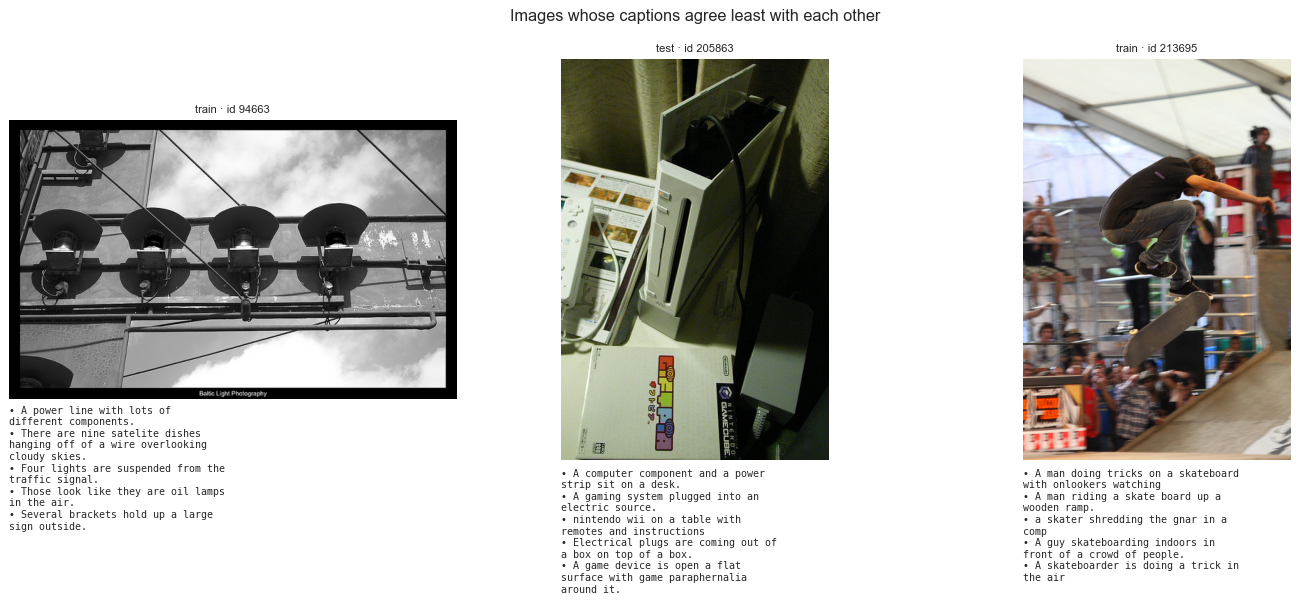

,split,cocoid,caption,consensus,flag_short,flag_long,flag_had_typo,flag_generic_start,flag_low_consensus
3,train,73,"A close up view of a motorized bicycle, sitting in a rack.",0.0,False,False,False,False,True
83,train,360,"An outside photo of signs, and lamp poles among the trees.",0.0,False,False,False,False,True
155,train,564,There is no image here to provide a description for.,0.0,False,False,False,False,True
170,train,590,A sink is shown with a mirror and lights.,0.0,False,False,False,False,True
201,train,675,A man drinking from a glass on top of a night stand.,0.0,False,False,False,False,True
223,train,715,A bunch of different fruits sitting in baskets and on a table.,0.0,False,False,False,False,True
243,train,761,a man in a yellow jacket standing next to some skiiers,0.0,False,False,False,False,True
297,train,873,"Chimneys point to the sky on a clear, sunny day.",0.0,False,False,False,False,True
396,train,1228,A picture of some animals that are eating off of the ground.,0.0,False,False,False,True,True
463,train,1525,A picture of a very big plan on the ground.,0.0,False,False,False,True,True


In [27]:
g = clean_df.groupby("cocoid").consensus
gap = (g.mean() - g.min()).sort_values(ascending=False)

def outlier_text(cid):
    sub = clean_df[clean_df.cocoid == cid].sort_values("raw_idx")
    worst = sub.consensus.idxmin()
    return "\n".join(textwrap.fill(f"{'>>' if i == worst else '• '} {c} [{s:.2f}]", 36) for i, c, s in zip(sub.index, sub.caption, sub.consensus))

show_images([(split_of[c], c, outlier_text(c)) for c in gap.head(6).index], 3, "consensus_outliers",
            "Lowest-consensus caption (>>) vs its siblings [consensus score]", text_lines=12)
agree = pd.Series(img_agree).sort_values()
show_images([(split_of[c], c, "\n".join(textwrap.fill(f"• {x}", 36) for x in lookup[c]["captions"])) for c in agree.head(3).index],
            3, "ambiguous_images", "Images whose captions agree least with each other", text_lines=12)
display(clean_df.nsmallest(10, "consensus")[["split", "cocoid", "caption", "consensus"] + flag_cols])

## Save all numbers

In [28]:
def jsonable(d):
    return {k: v for k, v in d.items() if isinstance(v, (int, float, str, bool, list, dict)) or v is None}

json.dump({"integrity": INTEGRITY, "text": jsonable(S_raw), "images": IMG_RAW, "objects": OBJ},
          open(ROOT / "eda" / "summary_raw.json", "w"), indent=1, default=float)
json.dump({"text": jsonable(S_clean), "images": IMG_CLEAN, "quality": QUALITY,
           "preprocessing_steps": STEP_LOG.to_dict("records"),
           "spelling": {"corrected_words": len(CORRECTIONS), "corrected_occurrences": n_tok_fixed, "left_unfixed": len(unfixed)},
           "vocab_size_with_specials": len(itos), "max_len": MAX_LEN, "truncated_share": trunc, "no_flip_images": len(NO_FLIP)},
          open(ROOT / "eda" / "summary_clean.json", "w"), indent=1, default=float)
print("saved eda/summary_raw.json, eda/summary_clean.json, eda/comparison.csv")

saved eda/summary_raw.json, eda/summary_clean.json, eda/comparison.csv
